# 3 · Training Diagnostics  `[TRAINING]`

The training-signal health, **not** the eval. For each arm: the TensorBoard curves you see on W&B (loss, reward, KL, …), the per-candidate reward spread, the method-native advantage signal, and a degeneration check. For a reader debugging *why* an arm did or didn't learn.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Training curves (TensorBoard)  `[TRAINING]`
**Purpose.** The optimiser-side curves per arm, chained across iterations (dotted lines = iteration boundaries): GRPO loss / reward / reward_std / KL / entropy / completion length; DPO loss / rewards / margins / accuracies / logps. Parsed straight from the run's event files.

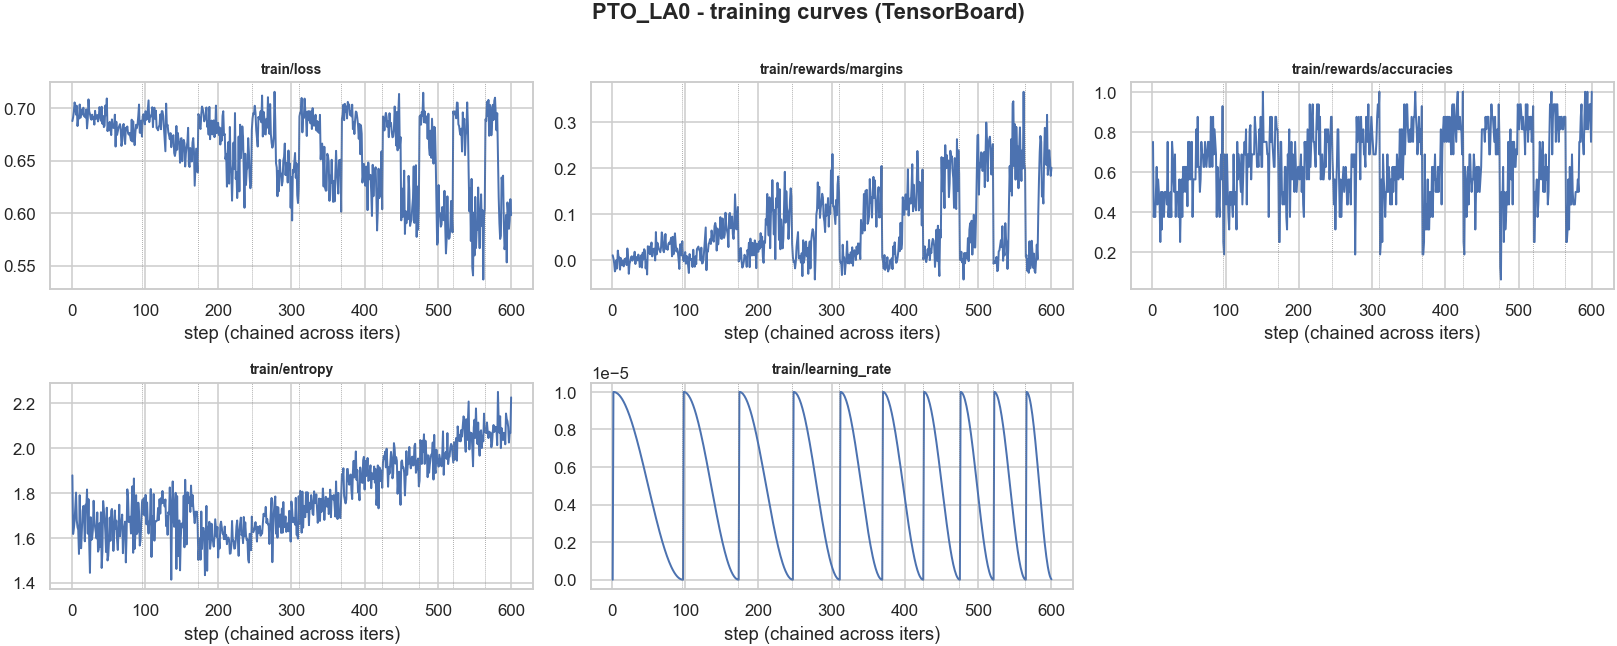

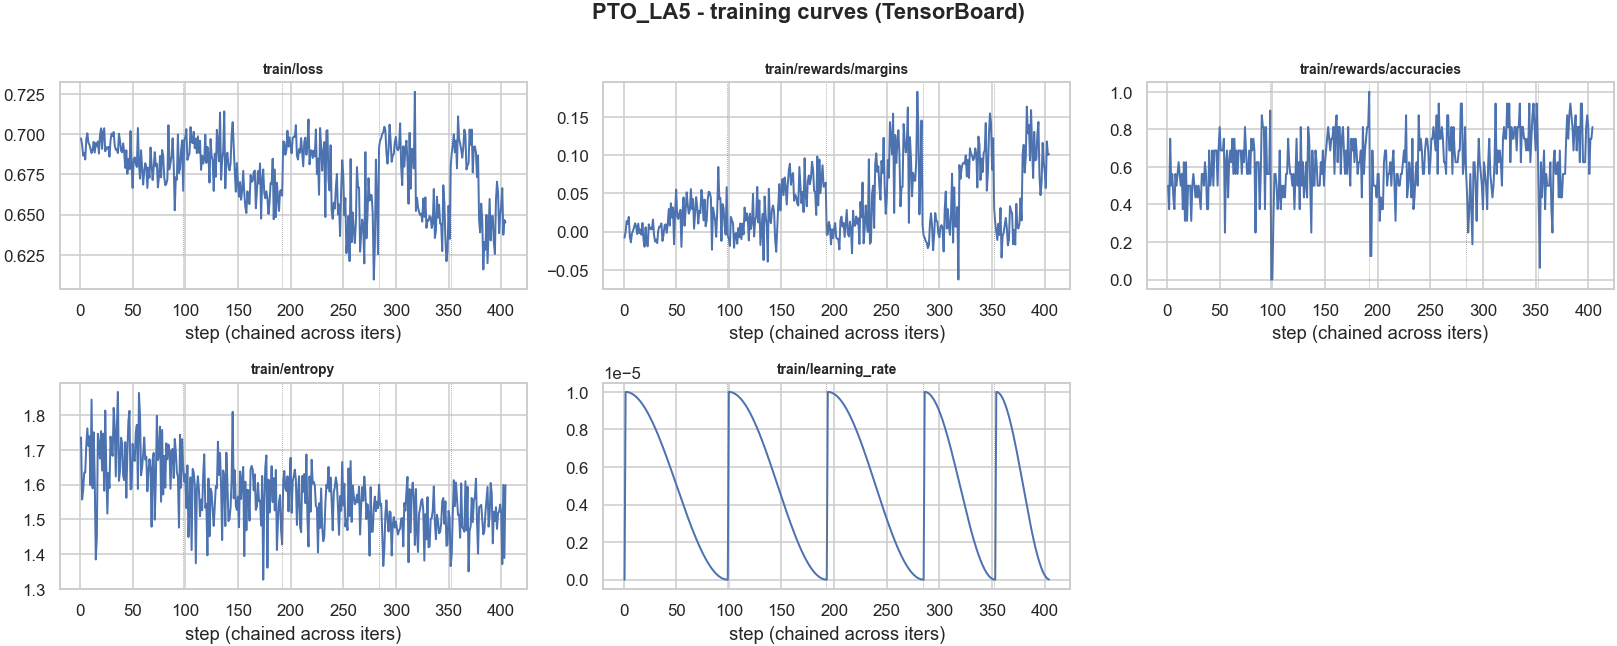

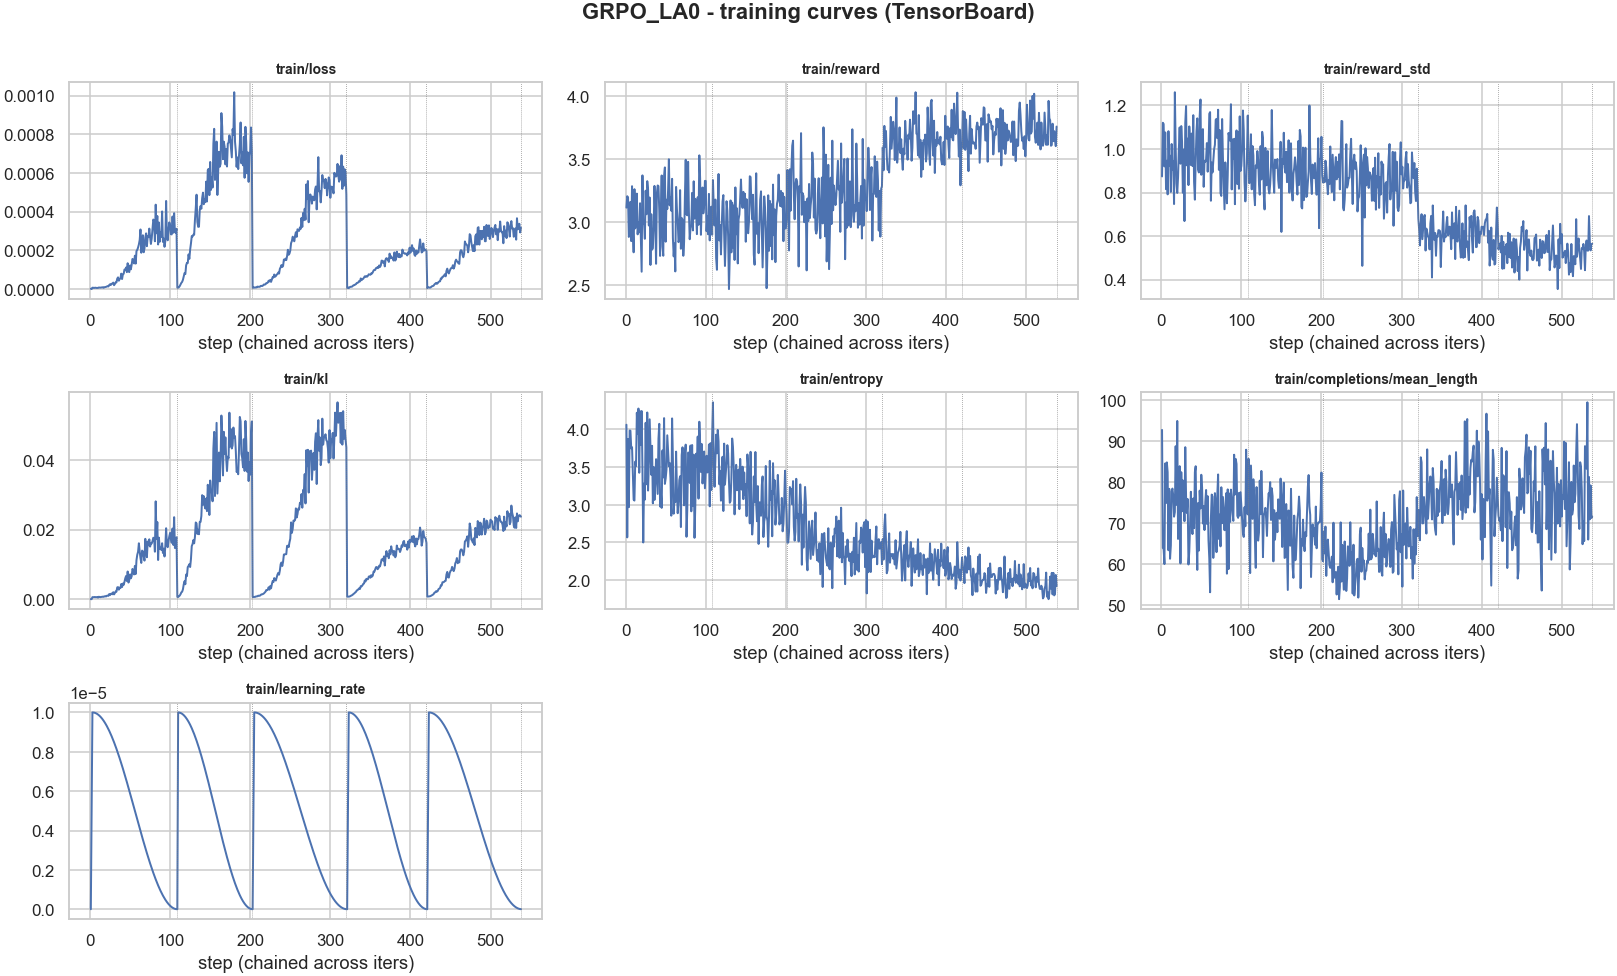

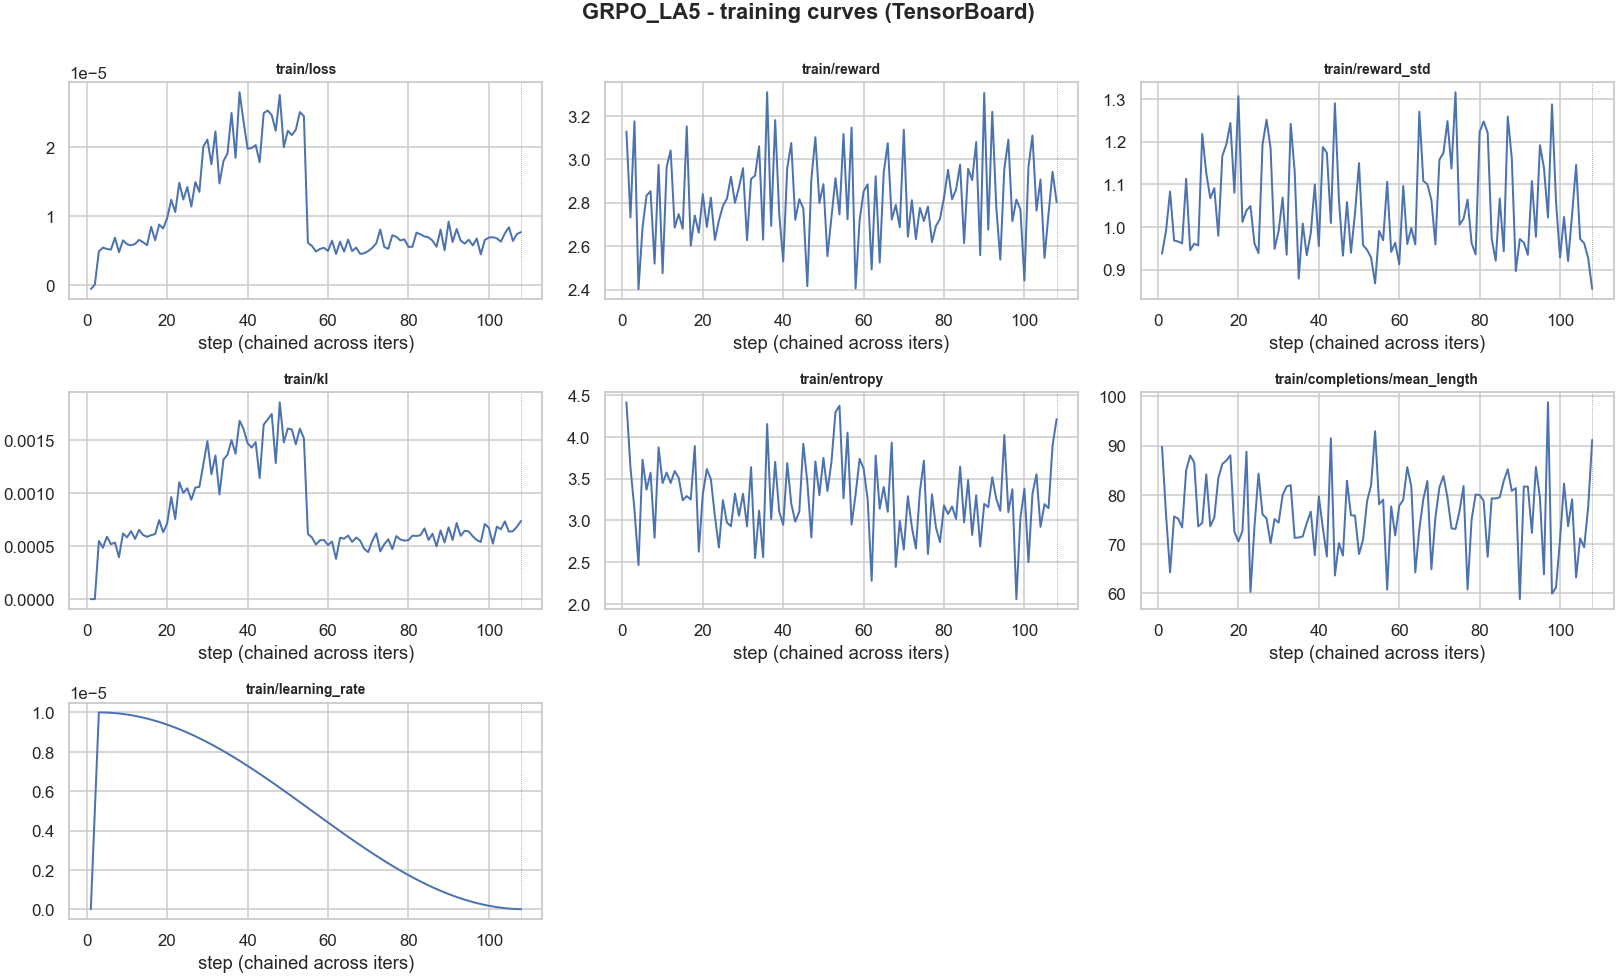

In [2]:
for arm in S.ARMS:
    fig = training.tb_curves(arm)
    if fig is not None:
        fig.suptitle(f"{arm.label} - training curves (TensorBoard)", y=1.0, fontweight="bold"); plt.show()

## 2 · Candidate reward + advantage signal  `[TRAINING]`
**Purpose.** What the oracle handed back per candidate (partial-branch reward), and the method-native advantage that drives the update — GRPO within-group reward spread (`group_std`; →0 = vanishing advantage) vs PTO chosen-rejected `margin`. **Read:** flat-lining of either signals saturation.

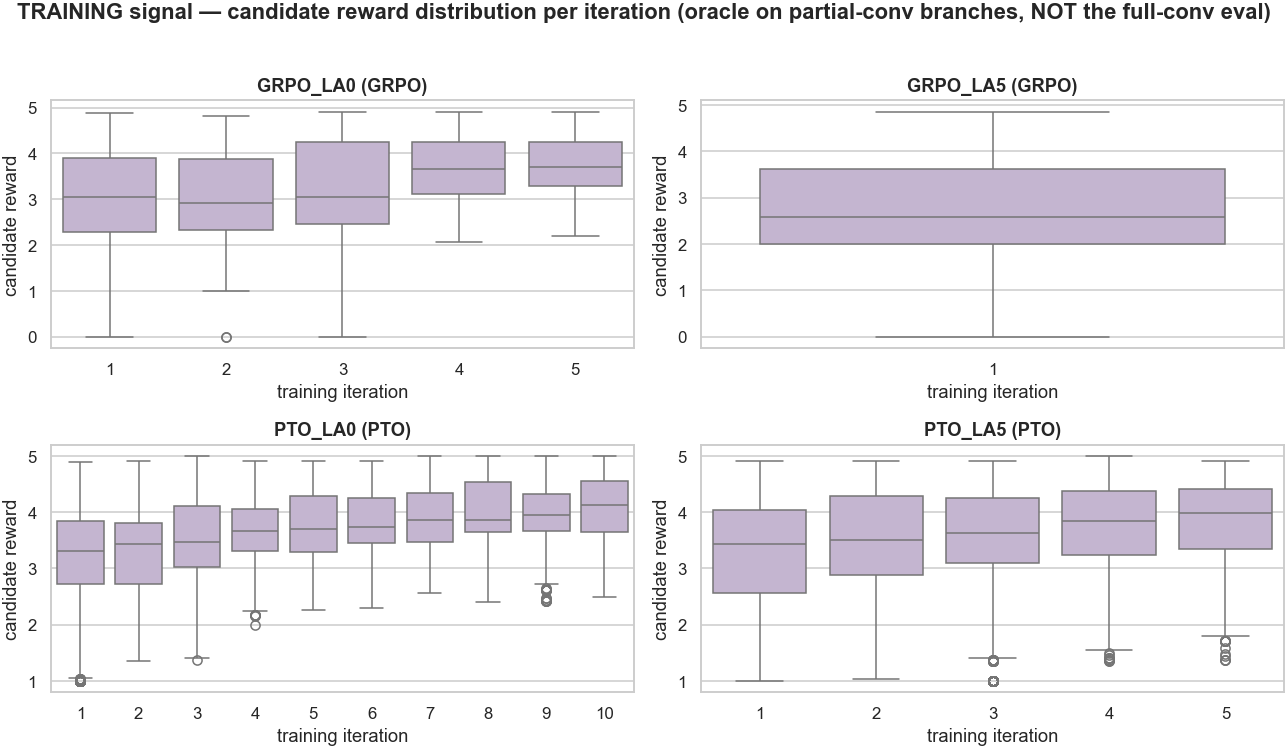

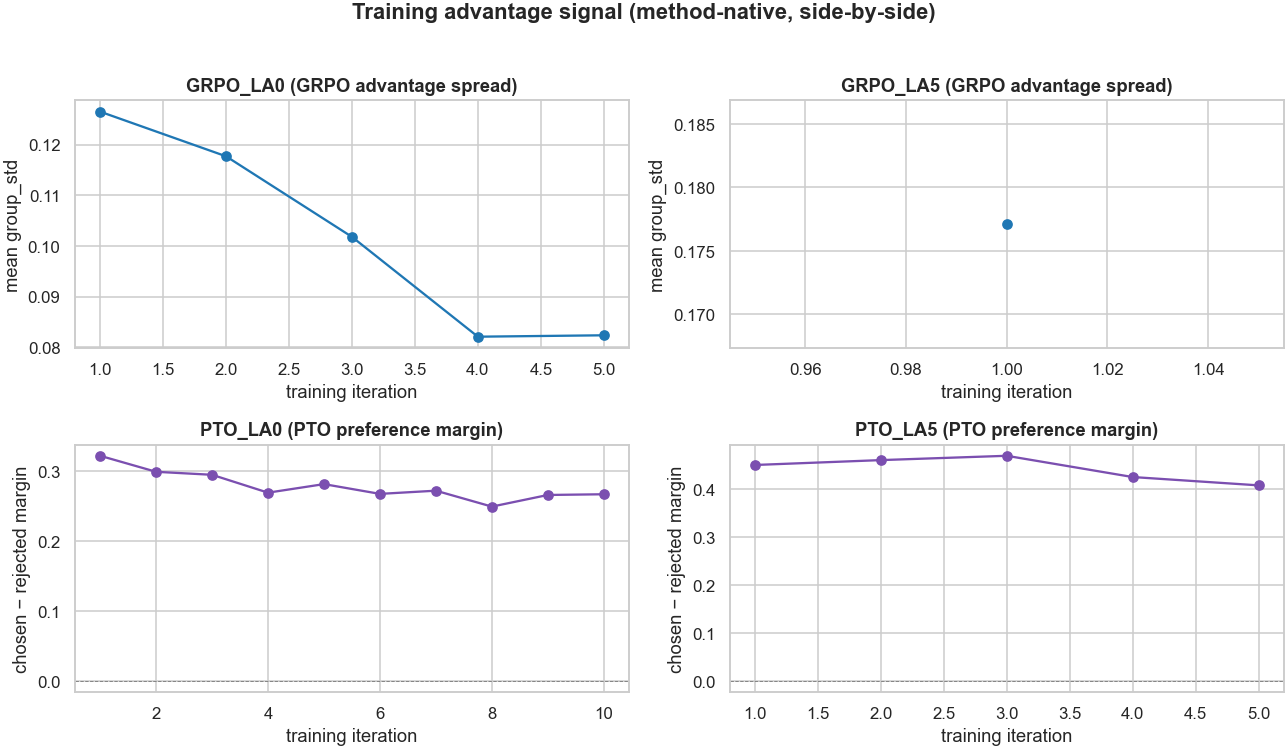

In [3]:
RWD = training.reward_distribution_frame(S.ARMS)
fig = plots.reward_distribution(RWD)
if fig: exp3.save_fig(fig, "reward_distribution_by_arm", caption="Per-candidate training reward per iteration, one panel per arm (oracle on partial-conv branches, not the full-conv eval)."); plt.show()
ADV = training.advantage_signal_by_iter(S.ARMS)
fig = plots.advantage_signal_sidebyside(ADV)
if fig: exp3.save_fig(fig, "advantage_signal_sidebyside", caption="Method-native training advantage: GRPO mean group_std vs PTO chosen-rejected margin, per iteration."); plt.show()

## 3 · Degeneration check  `[TRAINING]`
**Purpose.** Confirm the ChatML-leak / empty / floored-completion fixes held in the real runs. **Read:** `pct_leak`/`pct_empty` near 0 = clean; a spike flags a generation pathology that turn.

In [4]:
DEG = training.scan_degeneracy(training.load_generations(S.ARMS))
display(DEG[["arm", "train_iter", "n_candidates", "pct_leak", "pct_empty", "pct_floored", "mean_score"]] if not DEG.empty else DEG)

,arm,train_iter,n_candidates,pct_leak,pct_empty,pct_floored,mean_score
0,GRPO_LA0,1,14352,0.0,0.18,0.18,3.074450
1,GRPO_LA0,2,6160,0.0,0.03,0.03,3.043861
2,GRPO_LA0,3,16032,0.0,0.01,0.01,3.252195
3,GRPO_LA0,4,13440,0.0,0.00,0.00,3.662654
4,GRPO_LA0,5,15600,0.0,0.00,0.00,3.729112
5,GRPO_LA5,1,7160,0.0,0.21,0.21,2.813640
6,PTO_LA0,1,7592,0.0,0.24,0.00,3.290739
7,PTO_LA0,2,6176,0.0,0.13,0.00,3.332432
8,PTO_LA0,3,6296,0.0,0.30,0.00,3.536591
9,PTO_LA0,4,5176,0.0,0.15,0.00,3.663854


## 4 · How to read this notebook
- **Curves (§1)** are the ground truth of optimisation; a flat/exploding loss or collapsing `reward_std` explains a stalled arm.
- **Advantage (§2)** shrinking toward 0 (GRPO `group_std`, PTO `margin`) = the training signal is running out — expect the eval curve (`1_Eval_Results`) to plateau.
- **Degeneration (§3)** should stay ~0; this is the health gate, not a result.
- _(The held-out outcomes live in `1_Eval_Results`; whether this reward is *faithful* to them is `4_Reward_Reliability`.)_